# Exploratory Data Analysis of the Data

## Overview
This is tabular data for the HECKTOR Challenge 2026, its main use will be for completing Tasks 2 and 3. Hence, we need to make sure that the data is prepped for the following:
- Task 2: Predict TN-Staging
- Task 3: Predict recurrence-free survival

In layman terms, we need it to be prepared to fit some form of neural network or machine learning algorithm so that we can predict those two things.

## Exploring the Dataset As It Is

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

sns.set_style("darkgrid")

In [2]:
# Importing the dataset

df = pd.read_csv("./Data/HECKTOR_2026_training_data.csv")
df.head()

,PatientID,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS,T-stage,N-stage
0,CHUM-001,1.0,82.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1704.0,T2,N2
1,CHUM-002,1.0,73.0,1.0,NaN,NaN,NaN,1.0,NaN,1.0,439.0,T3,N1
2,CHUM-006,1.0,65.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1186.0,T2,N2
3,CHUM-007,1.0,70.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,1702.0,T2,N2
4,CHUM-008,1.0,67.0,0.0,NaN,NaN,NaN,1.0,NaN,0.0,1499.0,T2,N2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            782 non-null    object 
 1   CenterID             782 non-null    float64
 2   Age                  782 non-null    float64
 3   Gender               782 non-null    float64
 4   Tobacco Consumption  522 non-null    float64
 5   Alcohol Consumption  516 non-null    float64
 6   Performance Status   468 non-null    float64
 7   Treatment            763 non-null    float64
 8   HPV Status           597 non-null    float64
 9   Relapse              727 non-null    float64
 10  RFS                  727 non-null    float64
 11  T-stage              778 non-null    object 
 12  N-stage              782 non-null    object 
dtypes: float64(10), object(3)
memory usage: 79.6+ KB


Looking at this dataset's columns, we can see that our target features would be the following:
- Task 2:
    1. T-Stage
    2. N-Stage
- Task 3:
    1. Relapse (did the cancer come back? 0 or 1)
    2. RFS (how many days until relapse or last follow-up)

For Task 3 you need **both** Relapse and RFS together. That is the classic survival analysis setup (event + time). Relapse alone does not tell the whole story.

In [4]:
df.describe()

,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS
count,782.000000,782.000000,782.000000,522.000000,516.000000,468.000000,763.000000,597.000000,727.000000,727.000000
mean,4.335038,59.987468,0.835038,0.461686,0.637597,0.621795,0.836173,0.892797,0.203576,1638.778542
std,1.514006,9.211646,0.371383,0.499008,0.481161,0.725872,0.370361,0.309630,0.402935,1200.289138
min,1.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000
25%,3.000000,53.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,715.000000
50%,5.000000,59.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1295.000000
75%,5.000000,66.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2545.500000
max,8.000000,90.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,5888.000000


In [5]:
print(df.isnull().sum())

PatientID                0
CenterID                 0
Age                      0
Gender                   0
Tobacco Consumption    260
Alcohol Consumption    266
Performance Status     314
Treatment               19
HPV Status             185
Relapse                 55
RFS                     55
T-stage                  4
N-stage                  0
dtype: int64


In [6]:
df.shape

(782, 13)

As we can see, a fair number of missing values in the dataset, and a lot of data that seems to be normalized from 0 to 1 already. This might also be a case where its a categorical column, but the float dtype and the missing values might be messing with the mean. I need to figure out which columns are categorical and switch them out.

In [7]:
df.nunique()

PatientID              782
CenterID                 8
Age                     63
Gender                   2
Tobacco Consumption      2
Alcohol Consumption      2
Performance Status       5
Treatment                2
HPV Status               2
Relapse                  2
RFS                    648
T-stage                  5
N-stage                  4
dtype: int64

Ok, so we can see there are a lot of categorical columns in this. We need to make sure we can preprocess this later so that it's treated as categorical. 

## Cleaning the Dataset

Alright, we have poked around enough. Time to actually clean this up. We are going from a raw CSV to something a model can use.

Quick checklist:
- IDs are not duplicated
- Labels look valid (T1-T4, N0-N3, etc.)
- Missing values have a plan (fill features, drop bad label rows)
- Separate datasets for Tasks 2 and 3

Let's go.

In [8]:
# Column roles, easy to remember and access this way
ID_COL = "PatientID"

FEATURE_COLS = [
    "CenterID", "Age", "Gender", "Tobacco Consumption",
    "Alcohol Consumption", "Performance Status", "Treatment", "HPV Status",
]
CAT_COLS = [c for c in FEATURE_COLS if c != "Age"]  # Literally all the features are categorical except for Age

T_LABEL = "T-stage"
N_LABEL = "N-stage"
EVENT_COL = "Relapse"
TIME_COL = "RFS"

VALID_T = ["T0", "T1", "T2", "T3", "T4"]  # include T0 as a valid stage label
VALID_N = ["N0", "N1", "N2", "N3"]

print("Features:", FEATURE_COLS)
print("Task 2 labels:", T_LABEL, N_LABEL)
print("Task 3 labels:", EVENT_COL, TIME_COL)

Features: ['CenterID', 'Age', 'Gender', 'Tobacco Consumption', 'Alcohol Consumption', 'Performance Status', 'Treatment', 'HPV Status']
Task 2 labels: T-stage N-stage
Task 3 labels: Relapse RFS


`PatientID` is just an ID. We do not feed it to a model. We also do not impute labels (you cannot guess someone's T-stage). If a label is missing, that row gets dropped for that task. Features, on the other hand, we will fill in.

In [9]:
# Check patient IDs
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# Strip whitespace on stage labels (keep NaN as NaN)
for col in [T_LABEL, N_LABEL]:
    not_missing = df[col].notna()
    df.loc[not_missing, col] = df.loc[not_missing, col].astype(str).str.strip()

dup_count = df[ID_COL].duplicated().sum()
print("Duplicate PatientIDs:", dup_count)

Duplicate PatientIDs: 0


In [10]:
# Check labels look reasonable

print("=== Label counts ===\n")
for col in [T_LABEL, N_LABEL, EVENT_COL]:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

print("=== Unexpected values ===")
unexpected_t = set(df[T_LABEL].dropna()) - set(VALID_T)
unexpected_n = set(df[N_LABEL].dropna()) - set(VALID_N)

print("T-stage:", unexpected_t if unexpected_t else "none")
print("N-stage:", unexpected_n if unexpected_n else "none")

print("\n=== Sanity checks ===")
print("Negative RFS:", (df[TIME_COL] < 0).sum())

bad_relapse = df[EVENT_COL].notna() & ~df[EVENT_COL].isin([0, 1])
print("Bad Relapse values:", bad_relapse.sum())

print("Missing Relapse:", df[EVENT_COL].isna().sum())
print("Missing RFS:", df[TIME_COL].isna().sum())
print("Missing together:", df[EVENT_COL].isna().equals(df[TIME_COL].isna()))

=== Label counts ===

T-stage
T-stage
T2     285
T1     189
T3     183
T4     118
NaN      4
T0       3
Name: count, dtype: int64

N-stage
N-stage
N2    471
N3    148
N0     87
N1     76
Name: count, dtype: int64

Relapse
Relapse
0.0    579
1.0    148
NaN     55
Name: count, dtype: int64

=== Unexpected values ===
T-stage: none
N-stage: none

=== Sanity checks ===
Negative RFS: 0
Bad Relapse values: 0
Missing Relapse: 55
Missing RFS: 55
Missing together: True


/var/folders/qw/y3ys43gs7cdblx18lvtrz8r40000gn/T/ipykernel_2190/2935510397.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([has_t, missing_t], labels=['Has T-stage', 'Missing T-stage'])


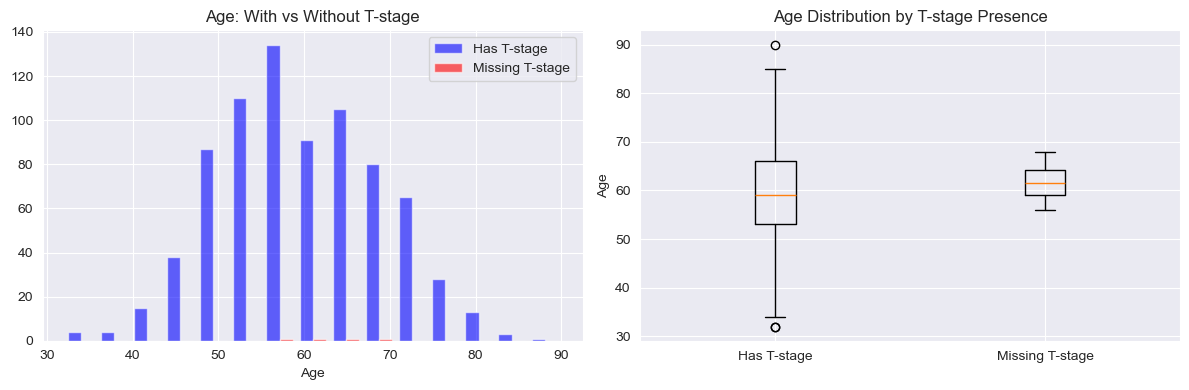

In [11]:
# Missing-target comparison: Age distribution for rows with vs without T-stage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

has_t = df[df[T_LABEL].notna()]['Age']
missing_t = df[df[T_LABEL].isna()]['Age']

axes[0].hist([has_t, missing_t], label=['Has T-stage', 'Missing T-stage'], bins=15, color=['blue', 'red'], alpha=0.6)
axes[0].set_title('Age: With vs Without T-stage')
axes[0].set_xlabel('Age')
axes[0].legend()

# Boxplot comparison
axes[1].boxplot([has_t, missing_t], labels=['Has T-stage', 'Missing T-stage'])
axes[1].set_title('Age Distribution by T-stage Presence')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

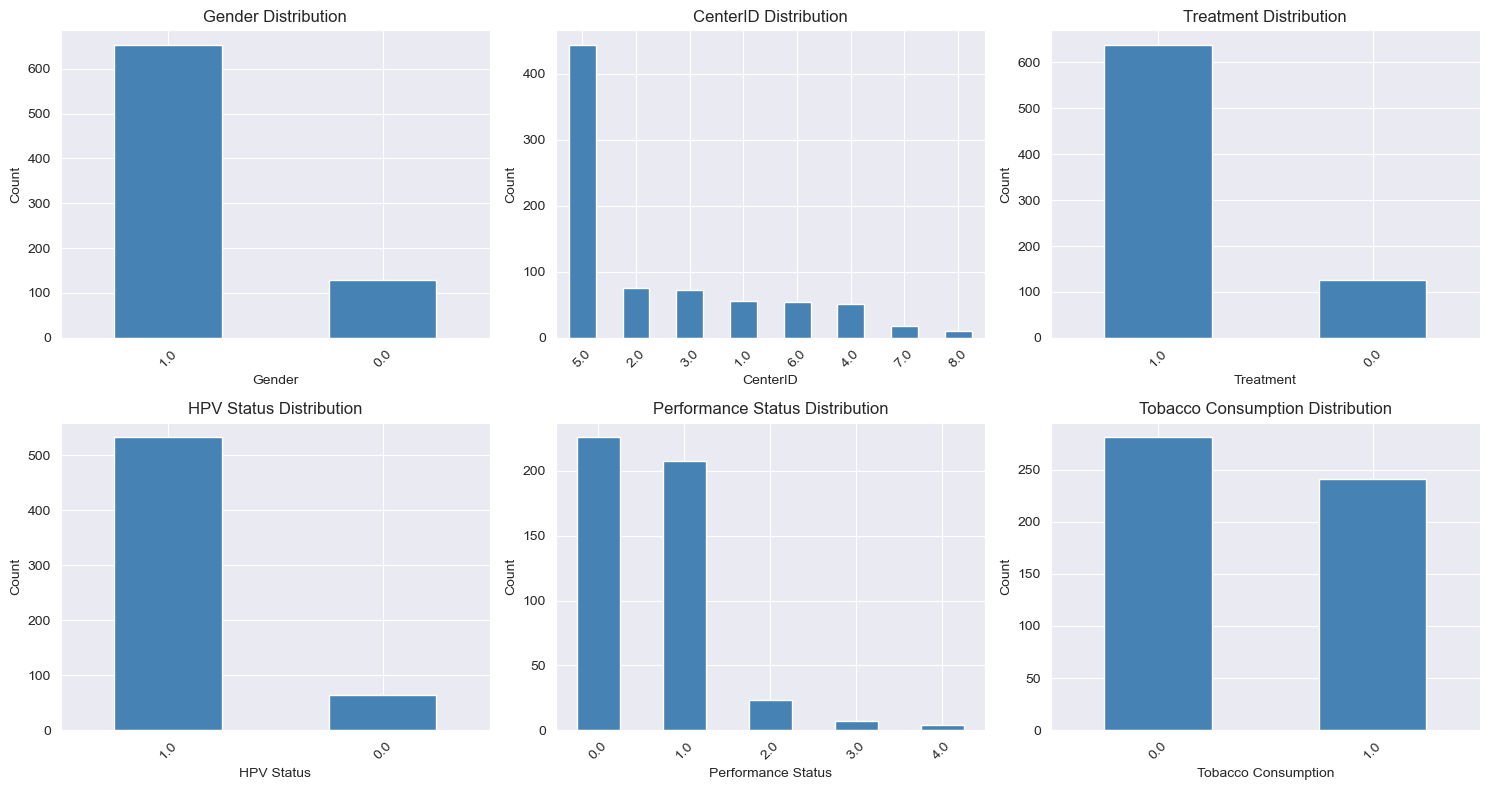

In [12]:
# Categorical feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cat_features = ['Gender', 'CenterID', 'Treatment', 'HPV Status', 'Performance Status', 'Tobacco Consumption']

for idx, col in enumerate(cat_features):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

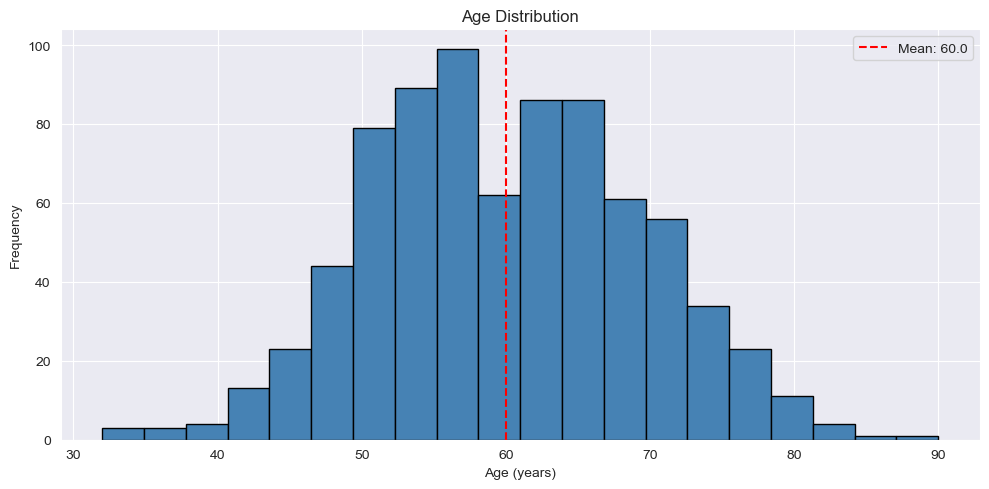

In [13]:
# Age histogram
plt.figure(figsize=(10, 5))
plt.hist(df['Age'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

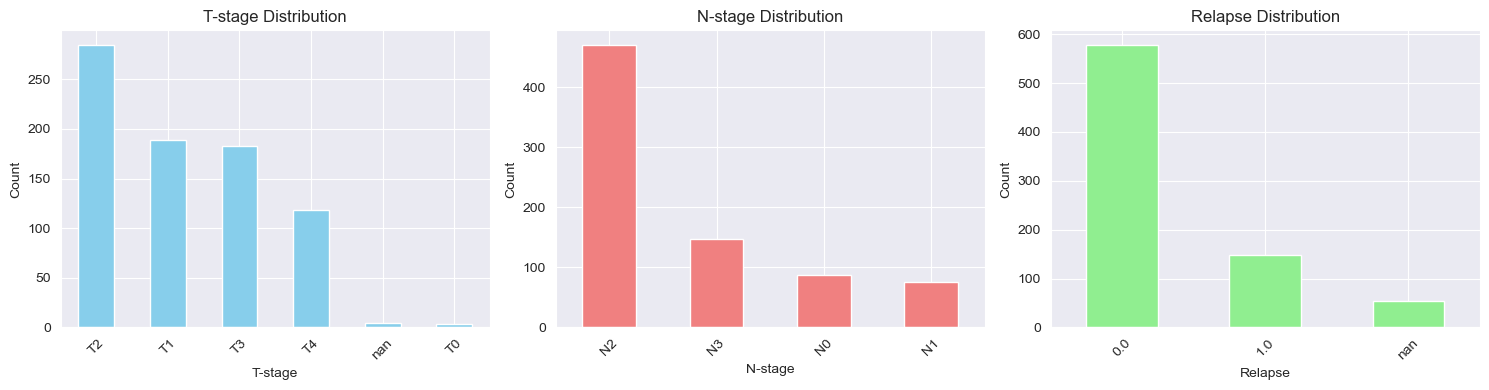

In [14]:
# Target label distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# T-stage
df[T_LABEL].value_counts(dropna=False).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('T-stage Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# N-stage
df[N_LABEL].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('N-stage Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Relapse
df[EVENT_COL].value_counts(dropna=False).plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Relapse Distribution')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

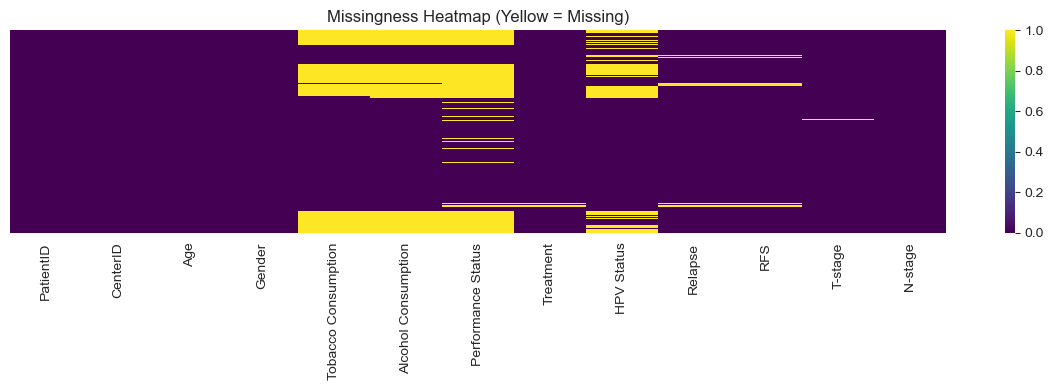

In [ ]:
# Missingness heatmap, shows patterns across rows
plt.figure(figsize=(12, 4))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missingness Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

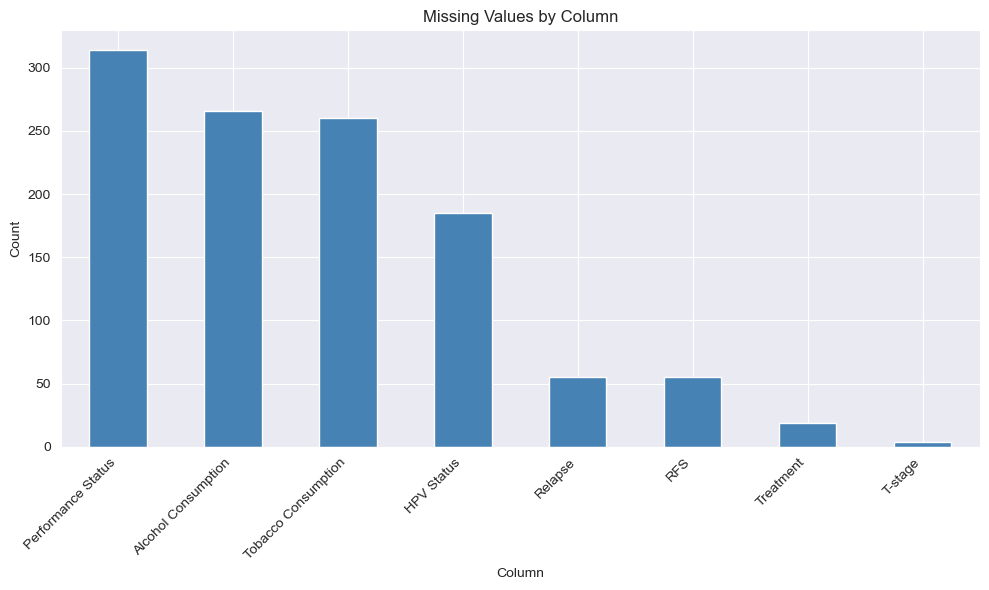

In [16]:
# Missing values bar chart
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]  # Only show columns with missing values

plt.figure(figsize=(10, 6))
missing.plot(kind='bar', color='steelblue')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Quality Visualizations

Let's visualize the data quality issues and distributions to understand what we're cleaning.

Yes, a lot of these columns are float64 in the CSV, so we will just make them categorical. 

In [17]:
# Mark categorical columns (Age stays numeric)
for col in CAT_COLS:
    df[col] = df[col].astype("category")

print(df[CAT_COLS].dtypes)

CenterID               category
Gender                 category
Tobacco Consumption    category
Alcohol Consumption    category
Performance Status     category
Treatment              category
HPV Status             category
dtype: object


In [18]:
# Fill missing feature values with -1 (means unknown)
df_clean = df.copy()

for col in CAT_COLS:
    df_clean[col] = df_clean[col].astype(float).fillna(-1)

df_clean.isnull().sum()

PatientID               0
CenterID                0
Age                     0
Gender                  0
Tobacco Consumption     0
Alcohol Consumption     0
Performance Status      0
Treatment               0
HPV Status              0
Relapse                55
RFS                    55
T-stage                 4
N-stage                 0
dtype: int64

In [19]:
# Build one dataframe per task
df_tn = df_clean.dropna(subset=[T_LABEL, N_LABEL]).copy()
df_rfs = df_clean.dropna(subset=[EVENT_COL, TIME_COL]).copy()

# Keep only expected stage labels (allowing T0 rows too)
valid_rows = df_tn[T_LABEL].isin(VALID_T) & df_tn[N_LABEL].isin(VALID_N)
invalid_count = (~valid_rows).sum()
df_tn = df_tn[valid_rows].copy()

print("Original rows:", len(df_clean))
print("Task 2 rows:", len(df_tn))
print("  dropped for missing T-stage:", df_clean[T_LABEL].isna().sum())
print("  dropped for invalid T/N stage:", invalid_count)
print("Task 3 rows:", len(df_rfs))
print("  dropped for missing Relapse/RFS:", df_clean[EVENT_COL].isna().sum())

Original rows: 782
Task 2 rows: 778
  dropped for missing T-stage: 4
  dropped for invalid T/N stage: 0
Task 3 rows: 727
  dropped for missing Relapse/RFS: 55


In [20]:
import os
# Save cleaned files
os.makedirs("./Data", exist_ok=True)

df_clean.to_csv("./Data/HECKTOR_2026_training_clean.csv", index=False)
df_tn.to_csv("./Data/task2_clean.csv", index=False)
df_rfs.to_csv("./Data/task3_clean.csv", index=False)

print("Saved cleaned CSV files to ./Data/")

Saved cleaned CSV files to ./Data/


### Cleaning recap

- **IDs:** stripped whitespace, checked for duplicates
- **Labels:** validated T/N stages and Relapse/RFS; dropped rows with missing labels per task
- **Invalid stages:** removed rows outside expected T1-T4 / N0-N3 (e.g. T0)
- **Features:** categorical columns filled with `-1` when missing (means unknown)
- **Outputs:** three CSVs saved in `./Data/`

Next up: preprocessing, turning this into numbers a model can use.

## Preprocessing

Cleaning fixes the data. Preprocessing makes it math-friendly.

In layman terms: scale Age, one-hot encode the categorical columns, and turn labels into numbers.

This is similar to what the repo baseline scripts do for clinical features. We are skipping the PET/CT images for now.

In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Just converting the categorical columns to strings.
def _make_cat_df(df):
    """Convert category columns to strings. -1 becomes 'Missing'."""
    cat_df = df[CAT_COLS].fillna(-1).astype(int).astype(str)
    return cat_df.replace("-1", "Missing")

# This is just scaling the Age column and one-hot encoding the categorical columns.
# This way, Age does not overpower the other features, and it becomes normalized.
def preprocess_features(df, scaler=None, ohe=None, fit=True):
    """Scale Age and one-hot encode categorical columns."""
    age = df[["Age"]]

    if fit:
        scaler = StandardScaler()
        age_scaled = scaler.fit_transform(age)
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        cat_encoded = ohe.fit_transform(_make_cat_df(df))
    else:
        age_scaled = scaler.transform(age)
        cat_encoded = ohe.transform(_make_cat_df(df))

    feature_names = ["Age"] + list(ohe.get_feature_names_out(CAT_COLS))
    X = np.hstack([age_scaled, cat_encoded])
    return X, scaler, ohe, feature_names

We're fitting the scaler and one-hot encoder on all cleaned rows here, which is fine for EDA. When we get to the ML section we'll refit on the **training split only** so we don't accidentally cheat. For now, this gets us a working pipeline.

In [22]:
# Task 2: features and labels
# df_tn already excludes invalid stages outside T0-T4 / N0-N3
X_tn, age_scaler, feature_ohe, feature_names = preprocess_features(df_tn, fit=True)

t_encoder = LabelEncoder().fit(VALID_T)
n_encoder = LabelEncoder().fit(VALID_N)

y_t = t_encoder.transform(df_tn[T_LABEL])
y_n = n_encoder.transform(df_tn[N_LABEL])

print("X_tn shape:", X_tn.shape)
print("T-stage classes:", list(t_encoder.classes_))
print("N-stage classes:", list(n_encoder.classes_))
print("Sample T labels:", y_t[:5])
print("Sample N labels:", y_n[:5])

X_tn shape: (778, 29)
T-stage classes: ['T0', 'T1', 'T2', 'T3', 'T4']
N-stage classes: ['N0', 'N1', 'N2', 'N3']
Sample T labels: [2 3 2 2 2]
Sample N labels: [2 1 2 2 2]


In [23]:
# Task 3: features and survival outcomes
X_rfs, _, _, _ = preprocess_features(
    df_rfs, scaler=age_scaler, ohe=feature_ohe, fit=False   # We fit the scaler and one-hot encoder on the training data, so we don't need to fit it again.
)

time = df_rfs[TIME_COL].astype(float).values
event = df_rfs[EVENT_COL].astype(int).values

print("X_rfs shape:", X_rfs.shape)
print("Event rate (Relapse=1):", round(event.mean(), 3))
print("Median RFS (days):", round(np.median(time), 1))
print("Median RFS (years):", round(np.median(time) / 365, 1))

X_rfs shape: (727, 29)
Event rate (Relapse=1): 0.204
Median RFS (days): 1295.0
Median RFS (years): 3.5


In [24]:
# Quick check that preprocessing looks okay
print("Rows:", X_tn.shape[0])
print("Features:", X_tn.shape[1])
print("Any NaNs:", np.isnan(X_tn).any())
print("Any infinities:", np.isinf(X_tn).any())
print("First few feature names:", feature_names[:5])

Rows: 778
Features: 29
Any NaNs: False
Any infinities: False
First few feature names: ['Age', 'CenterID_1', 'CenterID_2', 'CenterID_3', 'CenterID_4']


### Preprocessing done

| Variable | What it is |
|---|---|
| `X_tn`, `y_t`, `y_n` | Task 2 features + T/N labels |
| `X_rfs`, `time`, `event` | Task 3 features + survival outcome |

From here you can do statistical analysis or jump to a simple ML baseline.

## Statistical Analysis to Understand the Data

## Attempt at a Rudimentary Machine Learning Algorithm